## Week 7 – Outlier Detection & Data Quality

This section identifies extreme values in key numeric fields using statistical methods and evaluates their impact on the dataset.

In [2]:
import pandas as pd

sold = pd.read_csv("../output/sold_features.csv")

print(sold.shape)
sold.head()

/var/folders/j3/fcm5lwl97232mcc0j6k8vwnr0000gn/T/ipykernel_16069/2402021466.py:3: DtypeWarning: Columns (0,1,4,9,64,78,79,80,82,83) have mixed types. Specify dtype option on import or set low_memory=False.
  sold = pd.read_csv("../output/sold_features.csv")


(397123, 98)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,zero_coord_flag,invalid_longitude_flag,price_per_sqft,price_ratio,sale_to_list_ratio,year,month,year_month,listing_to_contract_days,contract_to_close_days
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,...,False,False,210.526316,0.480962,0.813559,2024,1,2024-01,777.0,65.0
1,SanDiego,SanDiego,NaN,False,NaN,NaN,False,759900.0,522107581,mdarwich12@gmail.com,...,False,False,412.867275,1.072510,1.072510,2024,1,2024-01,114.0,919.0
2,SanDiego,SanDiego,NaN,False,NaN,NaN,False,739900.0,510919001,mdarwich12@gmail.com,...,False,False,410.334347,1.094743,1.051948,2024,1,2024-01,255.0,778.0
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1079166779,davidmartz@compass.com,...,False,False,430.075188,NaN,1.000000,2024,1,2024-01,188.0,-188.0
4,Southland,Southland,NaN,False,NaN,NaN,False,1890500.0,1075037759,karen.klein@theagencyre.com,...,False,False,591.891046,1.000000,1.000000,2024,1,2024-01,0.0,0.0


### Key Fields for Outlier Detection

We focus on price, size, and market speed, as these heavily influence analysis results.

In [ ]:
cols = ['ClosePrice', 'LivingArea', 'DaysOnMarket']
sold[cols].describe()

### IQR Method (ClosePrice)

Identify extreme values using interquartile range.

In [4]:
Q1 = sold['ClosePrice'].quantile(0.25)
Q3 = sold['ClosePrice'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower, upper)

-512500.0 2387500.0


### Flag Outliers Instead of Removing

This preserves original data while identifying extreme values.

In [5]:
sold['price_outlier_flag'] = (
    (sold['ClosePrice'] < lower) |
    (sold['ClosePrice'] > upper)
)

sold['price_outlier_flag'].sum()

np.int64(29235)

In [7]:
# Repeat for LivingArea

Q1 = sold['LivingArea'].quantile(0.25)
Q3 = sold['LivingArea'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

sold['area_outlier_flag'] = (
    (sold['LivingArea'] < lower) |
    (sold['LivingArea'] > upper)
)

sold['area_outlier_flag'].sum()

np.int64(17522)

In [9]:
# Repeat for DaysOnMarket

Q1 = sold['DaysOnMarket'].quantile(0.25)
Q3 = sold['DaysOnMarket'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

sold['dom_outlier_flag'] = (
    (sold['DaysOnMarket'] < lower) |
    (sold['DaysOnMarket'] > upper)
)

sold['dom_outlier_flag'].sum()

np.int64(30195)

### Combined Outlier Indicator

In [10]:
sold['any_outlier_flag'] = (
    sold['price_outlier_flag'] |
    sold['area_outlier_flag'] |
    sold['dom_outlier_flag']
)

sold['any_outlier_flag'].sum()

np.int64(61907)

### Create Clean Dataset (Filtered)

Used for analysis without extreme values.

In [11]:
filtered = sold[sold['any_outlier_flag'] == False]

print("Original:", len(sold))
print("Filtered:", len(filtered))

Original: 397123
Filtered: 335216


### Impact of Outliers

Compare median values before and after filtering.

In [12]:
print("Original median price:", sold['ClosePrice'].median())
print("Filtered median price:", filtered['ClosePrice'].median())

Original median price: 820000.0
Filtered median price: 785000.0


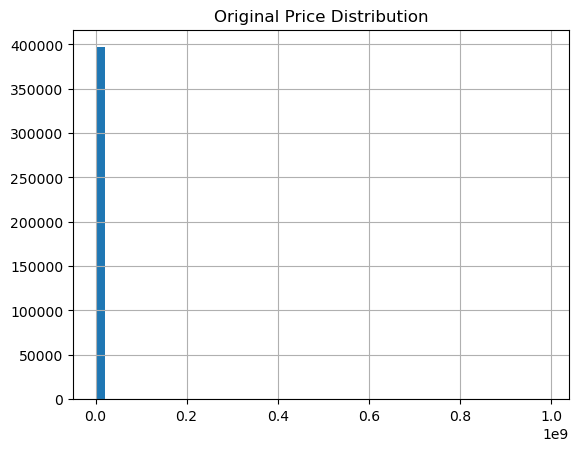

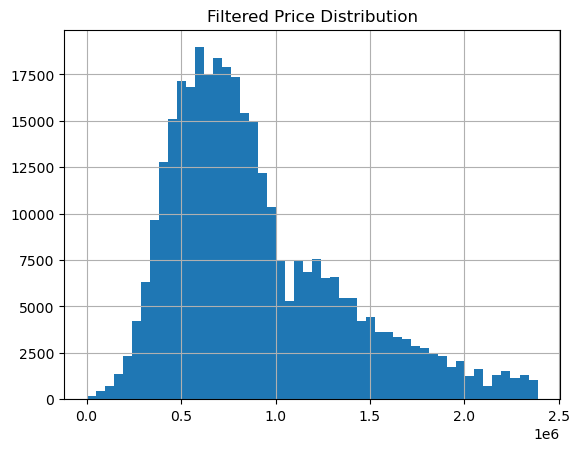

In [13]:
import matplotlib.pyplot as plt

sold['ClosePrice'].hist(bins=50)
plt.title("Original Price Distribution")
plt.show()

filtered['ClosePrice'].hist(bins=50)
plt.title("Filtered Price Distribution")
plt.show()

### Outlier Impact Interpretation

The original price distribution is heavily skewed due to extreme outliers, making it difficult to interpret typical market behavior. After removing outliers, the distribution becomes more balanced and reveals a clearer concentration of home prices. This demonstrates that extreme values can distort analysis and that filtering improves the reliability of insights.

In [14]:
# Save Both Versions

sold.to_csv("../output/sold_with_outliers_flagged.csv", index=False)
filtered.to_csv("../output/sold_filtered.csv", index=False)

print("Week 7 datasets saved")

Week 7 datasets saved


## Week 7 – Summary

- Identified extreme values in price, living area, and days on market using the IQR method  
- Flagged outliers instead of immediately removing them to preserve original data integrity  
- Created a filtered dataset excluding extreme values for more stable analysis  
- Observed that outliers can significantly impact median price and overall distribution  
- Prepared both flagged and filtered datasets for reliable downstream analytics and dashboard development  